In [112]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


The dataset

In [113]:
data = np.loadtxt("demo_logistic_regression.csv", delimiter=",", dtype=np.float64, skiprows=1)
X, y = data[:, :-1], data[:, -1].reshape((-1, 1))

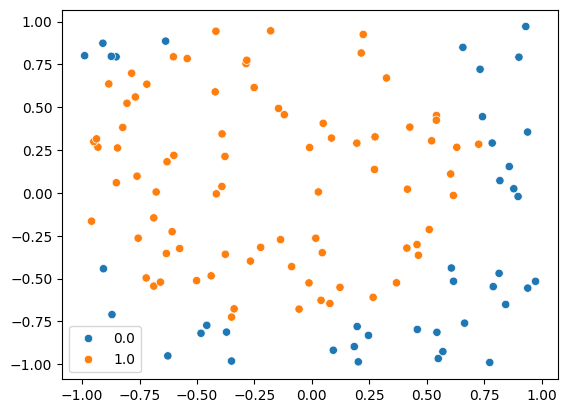

In [114]:
sns.scatterplot(x=X[:, 0], y=X[:,1], hue=y.flatten())   # the hue parameter is used to color the points based on their class labels
plt.show()

The Sigmoid Function

In [115]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

The Cross Entropy Loss Function

In [116]:
def loss(theta, X, y):
    h = sigmoid(np.dot(X, theta))
    cos = -(np.sum((y * np.log(h)) + (1 - y) * np.log(1 - h))) / len(y)
    return cos

The Gradient

In [117]:
def grad(theta, X, y):
    h = sigmoid(np.dot(X, theta))
    grad = np.dot(X.T, (h - y)) / len(y)
    return grad

The feature trick

In [118]:
def expand_features(x1, x2, power=2):
    # expand a 2D feature matrix to polynomial features up to the power.
    new_x = np.ones((x1.shape[0], 1))
    for i in range(1, power+1):
        for j in range(i+1):
             term = (x1 ** (i - j)) * (x2 ** j)
             new_x = np.c_[new_x, term]
            
    return new_x

In [119]:
def predict(theta, X):
    return (sigmoid(np.dot(X, theta)) > 0.5).astype(int).flatten()

Gradient Descent

In [120]:
def gradient_descent(X, y, theta, alpha, num_iters):
    m = len(y)
    costs = []

    for _ in range (num_iters):
        h = sigmoid(np.dot(X, theta))
        theta -= alpha * np.dot(X.T, (h - y)) / m
        costs.append(loss(theta, X, y))
    
    return theta, costs

Implement logistic regression

In [121]:
def logistic_regression(X, y, power,alpha, num_iters):
    expand_features(X[:, 0], X[:, 1], power)
    theta = np.zeros((X.shape[1], 1))
    theta, costs = gradient_descent(X, y, theta, alpha, num_iters)
    predicted = predict(theta, X)
    return predicted, theta, costs

Decide the polynomial power in the features, and the number of iterations

In [124]:
power, num_iters = 3, 1000
predicted, theta, costs = logistic_regression(X, y, power=power, alpha=1.5, num_iters=num_iters) 

In [125]:
print('The Accuracy is {:.2f} %'.format(sum(predicted == y.flatten()) / len(y) * 100))

The Accuracy is 66.67 %
